# Day 13: Supply Chain Supplier Risk Ranker

**Industry:** Transport / Logistics  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · numpy · matplotlib · seaborn · scoring model · datetime

**Data:** USAID SCMS Delivery History Dataset — 10,324 real health commodity shipments  
Source: USAID Supply Chain Management System (SCMS) — public domain

---

## Who uses this
A **procurement manager** deciding which supplier relationships to review this quarter. Instead of ranking suppliers in Excel with no consistent methodology, this notebook produces a composite risk scorecard combining on-time delivery rate, delay severity, and shipment volume for every vendor in the dataset.

## Problem
Procurement teams rank supplier risk inconsistently. Without a composite score, decisions are subjective and slow. This notebook standardises the methodology and produces an auditable, repeatable risk ranking.

## Dataset context
The SCMS dataset covers USAID-funded procurement of HIV/AIDS medicines and health commodities shipped to developing countries from 2006-2015. It contains real vendor names, scheduled vs actual delivery dates, freight costs, and shipment modes.

## What we build
1. Load and inspect real SCMS shipment data
2. Clean and engineer delay features
3. Calculate per-vendor: on-time rate, avg delay, delay severity, volume
4. Build composite risk score 1-10
5. Segment vendors into risk tiers
6. Analyse by shipment mode and country
7. Visualise 4-panel risk dashboard
8. Export supplier risk scorecard

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load and Inspect

In [2]:
df = pd.read_csv('scms_supply_chain.csv', encoding='latin1', low_memory=False)

print(f'Shape: {df.shape}')
print(f'\nKey columns null counts:')
key_cols = ['Vendor', 'Scheduled Delivery Date', 'Delivered to Client Date',
            'Shipment Mode', 'Country', 'Freight Cost (USD)', 'Line Item Value']
print(df[key_cols].isnull().sum().to_string())
print(f'\nTop 10 vendors by shipment count:')
print(df['Vendor'].value_counts().head(10).to_string())
print(f'\nShipment modes:')
print(df['Shipment Mode'].value_counts().to_string())
df.head(3)

Shape: (10324, 33)

Key columns null counts:
Vendor                        0
Scheduled Delivery Date       0
Delivered to Client Date      0
Shipment Mode               360
Country                       0
Freight Cost (USD)            0
Line Item Value               0

Top 10 vendors by shipment count:
Vendor
SCMS from RDC                                            5404
Orgenics, Ltd                                             754
S. BUYS WHOLESALER                                        715
Aurobindo Pharma Limited                                  668
Trinity Biotech, Plc                                      356
ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV)           347
PHARMACY DIRECT                                           326
MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORATORIES)     317
HETERO LABS LIMITED                                       277
CIPLA LIMITED                                             175

Shipment modes:
Shipment Mode
Air            6113
Truck          283

,ï»¿ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,CÃ´te d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.0,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.2,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,CÃ´te d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.0,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN


## Step 3 — Clean and Engineer Delay Features

In [3]:
df['scheduled_date'] = pd.to_datetime(df['Scheduled Delivery Date'], errors='coerce')
df['delivered_date'] = pd.to_datetime(df['Delivered to Client Date'], errors='coerce')
df['delay_days'] = (df['delivered_date'] - df['scheduled_date']).dt.days

df_clean = df.dropna(subset=['delay_days', 'Vendor']).copy()
df_clean = df_clean[df_clean['delay_days'].between(-365, 730)]
df_clean['is_late'] = (df_clean['delay_days'] > 0).astype(int)

def delay_severity(days):
    if days <= 0:    return 'On Time / Early'
    elif days <= 7:  return 'Slightly Late (1-7d)'
    elif days <= 30: return 'Moderately Late (8-30d)'
    else:            return 'Severely Late (30d+)'

df_clean['delay_severity'] = df_clean['delay_days'].apply(delay_severity)

df_clean['freight_cost'] = pd.to_numeric(
    df_clean['Freight Cost (USD)'].astype(str).str.replace('[,$]', '', regex=True).str.strip(),
    errors='coerce')

df_clean['line_item_value'] = pd.to_numeric(
    df_clean['Line Item Value'].astype(str).str.replace('[,$]', '', regex=True).str.strip(),
    errors='coerce')

df_clean['vendor'] = df_clean['Vendor'].str.strip().str.title()

overall_late_rate = df_clean['is_late'].mean() * 100
print(f'Clean rows:            {len(df_clean):,}')
print(f'Overall late rate:     {overall_late_rate:.1f}%')
print(f'Avg delay (all):       {df_clean["delay_days"].mean():.1f} days')
print(f'Avg delay (late only): {df_clean[df_clean["is_late"]==1]["delay_days"].mean():.1f} days')
print(f'\nDelay severity breakdown:')
print(df_clean['delay_severity'].value_counts().to_string())

Clean rows:            10,320
Overall late rate:     11.5%
Avg delay (all):       -5.9 days
Avg delay (late only): 21.4 days

Delay severity breakdown:
delay_severity
On Time / Early            9134
Moderately Late (8-30d)     536
Slightly Late (1-7d)        420
Severely Late (30d+)        230


## Step 4 — Calculate Per-Vendor Metrics

In [4]:
vendor_metrics = (
    df_clean.groupby('vendor')
    .agg(
        total_shipments=('is_late', 'count'),
        late_shipments=('is_late', 'sum'),
        on_time_rate=('is_late', lambda x: round((1 - x.mean()) * 100, 1)),
        avg_delay_days=('delay_days', 'mean'),
        max_delay_days=('delay_days', 'max'),
        severe_delay_rate=('delay_severity', lambda x: round((x == 'Severely Late (30d+)').mean() * 100, 1)),
        total_value_usd=('line_item_value', 'sum'),
        avg_freight_cost=('freight_cost', 'mean')
    )
    .query('total_shipments >= 5')
    .round(1)
    .reset_index()
)

print(f'Vendors with 5+ shipments: {len(vendor_metrics)}')
print(f'\nTop 10 worst vendors by on-time rate:')
print(vendor_metrics.sort_values('on_time_rate')
      [['vendor','total_shipments','on_time_rate','avg_delay_days','severe_delay_rate']]
      .head(10).to_string())
print(f'\nTop 10 best vendors by on-time rate:')
print(vendor_metrics.sort_values('on_time_rate', ascending=False)
      [['vendor','total_shipments','on_time_rate','avg_delay_days']]
      .head(10).to_string())

Vendors with 5+ shipments: 37

Top 10 worst vendors by on-time rate:
                                                              vendor  total_shipments  on_time_rate  avg_delay_days  severe_delay_rate
30                                                     Scms From Rdc             5401          82.8            -8.1                2.8
5                                      Bio-Rad Laboratories (France)               28          85.7             2.1                3.6
4                                           Aurobindo Pharma Limited              668          85.9             4.4                6.4
9                                                      Cipla Limited              175          86.9             4.8                6.9
25                                                     Orgenics, Ltd              754          87.0             0.8                1.5
34  Sun Pharmaceutical Industries Ltd (Ranbaxy Laboratories Limited)                9          88.9             0.3      

## Step 5 — Build Composite Risk Score

Three normalised components weighted into a risk score 0-10:
- **Late rate score** (50% weight)
- **Severity score** (30% weight)
- **Avg delay score** (20% weight)

In [5]:
def normalise(series):
    min_val, max_val = series.min(), series.max()
    if max_val == min_val:
        return pd.Series([5.0] * len(series), index=series.index)
    return (series - min_val) / (max_val - min_val) * 10

vendor_metrics['late_rate_score'] = normalise(100 - vendor_metrics['on_time_rate'])
vendor_metrics['severity_score']  = normalise(vendor_metrics['severe_delay_rate'])
vendor_metrics['avg_delay_score'] = normalise(vendor_metrics['avg_delay_days'].clip(lower=0))

vendor_metrics['risk_score'] = (
    vendor_metrics['late_rate_score'] * 0.50 +
    vendor_metrics['severity_score']  * 0.30 +
    vendor_metrics['avg_delay_score'] * 0.20
).round(2)

vendor_metrics['risk_tier'] = pd.cut(
    vendor_metrics['risk_score'],
    bins=[0, 3.33, 6.66, 10],
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    include_lowest=True
)

vendor_metrics = vendor_metrics.sort_values('risk_score', ascending=False).reset_index(drop=True)

print('=== Risk tier breakdown ===')
print(vendor_metrics['risk_tier'].value_counts().to_string())
print('\n=== Top 15 highest risk vendors ===')
print(vendor_metrics[['vendor','total_shipments','on_time_rate',
                       'avg_delay_days','severe_delay_rate','risk_score','risk_tier']]
      .head(15).to_string())

=== Risk tier breakdown ===
risk_tier
Low Risk       30
Medium Risk     5
High Risk       2

=== Top 15 highest risk vendors ===
                                                              vendor  total_shipments  on_time_rate  avg_delay_days  severe_delay_rate  risk_score    risk_tier
0                                                      Cipla Limited              175          86.9             4.8                6.9        8.81    High Risk
1                                           Aurobindo Pharma Limited              668          85.9             4.4                6.4        8.71    High Risk
2                                      Bio-Rad Laboratories (France)               28          85.7             2.1                3.6        6.60  Medium Risk
3                                                      Scms From Rdc             5401          82.8            -8.1                2.8        6.22  Medium Risk
4                                                      Orgenics, Ltd   

## Step 6 — Analysis by Shipment Mode and Country

In [6]:
by_mode = (
    df_clean.groupby('Shipment Mode')
    .agg(
        shipments=('is_late', 'count'),
        late_rate=('is_late', 'mean'),
        avg_delay=('delay_days', 'mean'),
        avg_freight=('freight_cost', 'mean')
    )
    .assign(late_rate=lambda x: (x['late_rate'] * 100).round(1))
    .round(1)
    .sort_values('late_rate', ascending=False)
    .reset_index()
)

by_country = (
    df_clean.groupby('Country')
    .agg(
        shipments=('is_late', 'count'),
        late_rate=('is_late', 'mean'),
        avg_delay=('delay_days', 'mean')
    )
    .query('shipments >= 20')
    .assign(late_rate=lambda x: (x['late_rate'] * 100).round(1))
    .round(1)
    .sort_values('late_rate', ascending=False)
    .head(15)
    .reset_index()
)

severity_dist = df_clean['delay_severity'].value_counts()

print('=== Late rate by shipment mode ===')
print(by_mode.to_string())
print('\n=== Top 15 countries by late rate (min 20 shipments) ===')
print(by_country.to_string())

=== Late rate by shipment mode ===
  Shipment Mode  shipments  late_rate  avg_delay  avg_freight
0         Ocean        371       17.5        5.9      12733.1
1         Truck       2827       16.1       -9.5      10171.2
2   Air Charter        650       11.5      -19.0      21052.1
3           Air       6113        9.6       -3.8      10459.0

=== Top 15 countries by late rate (min 20 shipments) ===
           Country  shipments  late_rate  avg_delay
0          Burundi         98       38.8       -8.4
1       Congo, DRC        333       24.9       11.2
2       Mozambique        631       18.4       -1.2
3           Zambia        683       15.8       -5.2
4         Zimbabwe        538       14.3      -11.0
5            Ghana         58       13.8       -0.2
6      South Sudan        164       12.8       -1.1
7         Tanzania        518       12.7       -3.7
8           Uganda        779       12.6       -7.6
9            Kenya        111       12.6        0.9
10  CÃ´te d'Ivoire       

## Step 7 — Visualise: 4-Panel Risk Dashboard

Dashboard saved as supplier_risk_analysis.png


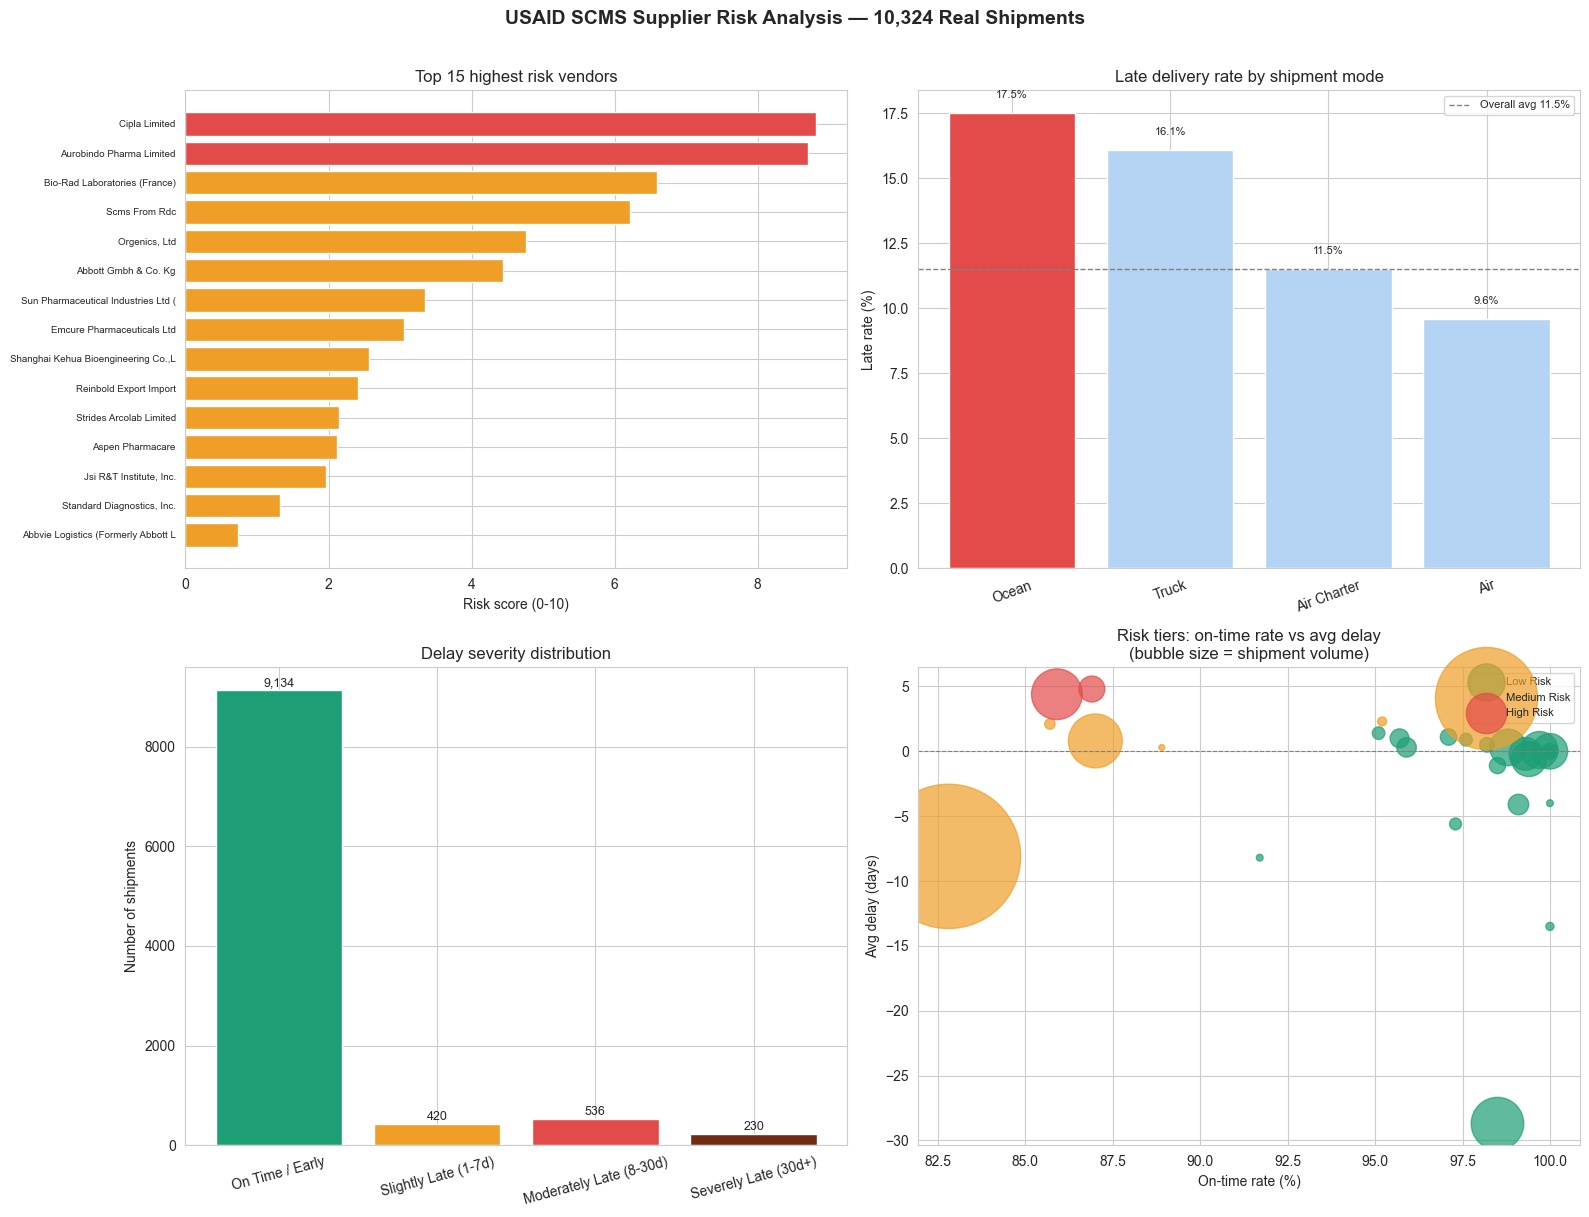

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('USAID SCMS Supplier Risk Analysis — 10,324 Real Shipments',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1 — Top 15 highest risk vendors
top15 = vendor_metrics.head(15)
risk_colors = ['#E24B4A' if t == 'High Risk' else '#EF9F27' for t in top15['risk_tier']]
axes[0, 0].barh(top15['vendor'].str[:35], top15['risk_score'], color=risk_colors)
axes[0, 0].set_xlabel('Risk score (0-10)')
axes[0, 0].set_title('Top 15 highest risk vendors')
axes[0, 0].invert_yaxis()
axes[0, 0].tick_params(axis='y', labelsize=7)

# Panel 2 — Late rate by shipment mode
mode_colors = ['#E24B4A' if v == by_mode['late_rate'].max() else '#B5D4F4' for v in by_mode['late_rate']]
bars = axes[0, 1].bar(by_mode['Shipment Mode'], by_mode['late_rate'], color=mode_colors)
axes[0, 1].axhline(overall_late_rate, color='gray', linestyle='--', linewidth=1,
                   label=f'Overall avg {overall_late_rate:.1f}%')
axes[0, 1].set_ylabel('Late rate (%)')
axes[0, 1].set_title('Late delivery rate by shipment mode')
axes[0, 1].legend(fontsize=8)
axes[0, 1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, by_mode['late_rate']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val}%', ha='center', va='bottom', fontsize=8)

# Panel 3 — Delay severity distribution
sev_order  = ['On Time / Early', 'Slightly Late (1-7d)', 'Moderately Late (8-30d)', 'Severely Late (30d+)']
sev_colors = ['#1D9E75', '#EF9F27', '#E24B4A', '#712B13']
sev_vals   = [severity_dist.get(s, 0) for s in sev_order]
axes[1, 0].bar(sev_order, sev_vals, color=sev_colors)
axes[1, 0].set_ylabel('Number of shipments')
axes[1, 0].set_title('Delay severity distribution')
axes[1, 0].tick_params(axis='x', rotation=15)
for i, val in enumerate(sev_vals):
    axes[1, 0].text(i, val + 20, f'{val:,}', ha='center', va='bottom', fontsize=9)

# Panel 4 — Risk tier scatter
tier_colors_map = {'Low Risk': '#1D9E75', 'Medium Risk': '#EF9F27', 'High Risk': '#E24B4A'}
for tier, group in vendor_metrics.groupby('risk_tier'):
    axes[1, 1].scatter(group['on_time_rate'], group['avg_delay_days'],
                       c=tier_colors_map[tier], label=tier, alpha=0.7,
                       s=group['total_shipments'] * 2)
axes[1, 1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1, 1].set_xlabel('On-time rate (%)')
axes[1, 1].set_ylabel('Avg delay (days)')
axes[1, 1].set_title('Risk tiers: on-time rate vs avg delay\n(bubble size = shipment volume)')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('supplier_risk_analysis.png', dpi=150, bbox_inches='tight')
print('Dashboard saved as supplier_risk_analysis.png')
plt.show()

## Step 8 — Export + Business Insight Summary

In [8]:
os.makedirs('output', exist_ok=True)

vendor_metrics.to_csv('output/supplier_risk_scorecard.csv', index=False)
vendor_metrics[vendor_metrics['risk_tier'] == 'High Risk'].to_csv('output/high_risk_vendors.csv', index=False)
by_mode.to_csv('output/late_rate_by_mode.csv', index=False)
by_country.to_csv('output/late_rate_by_country.csv', index=False)

high_risk    = vendor_metrics[vendor_metrics['risk_tier'] == 'High Risk']
worst_vendor = vendor_metrics.iloc[0]
worst_mode   = by_mode.iloc[0]
best_mode    = by_mode.iloc[-1]

print('=' * 60)
print('BUSINESS INSIGHT SUMMARY')
print('=' * 60)
print(f'Total shipments analysed:  {len(df_clean):,}')
print(f'Vendors scored:            {len(vendor_metrics)}')
print(f'Overall late rate:         {overall_late_rate:.1f}%')
print(f'Avg delay (late only):     {df_clean[df_clean["is_late"]==1]["delay_days"].mean():.1f} days')
print()
print(f'Risk tier breakdown:')
for tier, count in vendor_metrics['risk_tier'].value_counts().items():
    print(f'  {tier:15s}: {count} vendors')
print()
print(f'Highest risk vendor:  {worst_vendor["vendor"]}')
print(f'  Risk score:         {worst_vendor["risk_score"]}/10')
print(f'  On-time rate:       {worst_vendor["on_time_rate"]}%')
print(f'  Avg delay:          {worst_vendor["avg_delay_days"]} days')
print(f'  Severe delay rate:  {worst_vendor["severe_delay_rate"]}%')
print()
print(f'Worst shipment mode:  {worst_mode["Shipment Mode"]} — {worst_mode["late_rate"]}% late rate')
print(f'Best shipment mode:   {best_mode["Shipment Mode"]} — {best_mode["late_rate"]}% late rate')
print()
print(f'High risk vendors flagged: {len(high_risk)}')
print()
print('PROCUREMENT RECOMMENDATIONS:')
print(f'  1. Audit {worst_vendor["vendor"]} — highest risk score {worst_vendor["risk_score"]}/10')
print(f'  2. Review {worst_mode["Shipment Mode"]} shipments — {worst_mode["late_rate"]}% late rate')
print(f'  3. {len(high_risk)} vendors flagged High Risk — renegotiate SLAs or find alternatives')
print(f'  4. Prefer {best_mode["Shipment Mode"]} where possible — lowest late rate')
print('=' * 60)

BUSINESS INSIGHT SUMMARY
Total shipments analysed:  10,320
Vendors scored:            37
Overall late rate:         11.5%
Avg delay (late only):     21.4 days

Risk tier breakdown:
  Low Risk       : 30 vendors
  Medium Risk    : 5 vendors
  High Risk      : 2 vendors

Highest risk vendor:  Cipla Limited
  Risk score:         8.81/10
  On-time rate:       86.9%
  Avg delay:          4.8 days
  Severe delay rate:  6.9%

Worst shipment mode:  Ocean — 17.5% late rate
Best shipment mode:   Air — 9.6% late rate

High risk vendors flagged: 2

PROCUREMENT RECOMMENDATIONS:
  1. Audit Cipla Limited — highest risk score 8.81/10
  2. Review Ocean shipments — 17.5% late rate
  3. 2 vendors flagged High Risk — renegotiate SLAs or find alternatives
  4. Prefer Air where possible — lowest late rate


## Summary

### Skills practised
- `pandas` — datetime parsing, timedelta, groupby, agg, query, clip
- `numpy` — normalisation
- `matplotlib` + `seaborn` — 4-panel dashboard, bubble scatter
- Scoring model — weighted composite with normalisation
- Supply chain metrics — on-time rate, delay severity, risk tiering

### Key findings
Fill these in from your output:
- Overall late rate: 11.5%
- Highest risk vendor: Cipla Limited
- Worst shipment mode: Ocean — 17.5% late rate
- High risk vendors flagged: 2 vendors
- Best shipment mode: Air — 9.6% late rate